# Keras Tutorial
- See https://keras.io


In [1]:
import keras
keras.__version__

'3.15.1'

## 1. Dataset

We will use a built-in data set called 'MNIST,' which contains handwritten digit number images ranging from 0 to 9.

In [2]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

### Type of dataset

In [3]:
print('Feature type: %s'%type(train_images))
print('Label type: %s'%type(train_labels))

Feature type: <class 'numpy.ndarray'>
Label type: <class 'numpy.ndarray'>


### Type of value in the dataset

In [4]:
print('Feature data type: %s'%train_images.dtype)
print('Label data type: %s'%train_labels.dtype)

Feature data type: uint8
Label data type: uint8


### Shape

In [5]:
print('Train_set Feature shape: %s'%str(train_images.shape))
print('Train_set Label type: %s'%str(train_labels.shape))
print('Test_set Feature shape: %s'%str(test_images.shape))
print('Test_set Label type: %s'%str(test_labels.shape))

Train_set Feature shape: (60000, 28, 28)
Train_set Label type: (60000,)
Test_set Feature shape: (10000, 28, 28)
Test_set Label type: (10000,)


### Dimension

In [6]:
print('Train_set Feature dimension: %s'%str(train_images.ndim))
print('Train_set Label dimension: %s'%str(train_labels.ndim))
print('Test_set Feature dimension: %s'%str(test_images.ndim))
print('Test_set Label dimension: %s'%str(test_labels.ndim))

Train_set Feature dimension: 3
Train_set Label dimension: 1
Test_set Feature dimension: 3
Test_set Label dimension: 1


### Characteristic of data

In [7]:
train_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

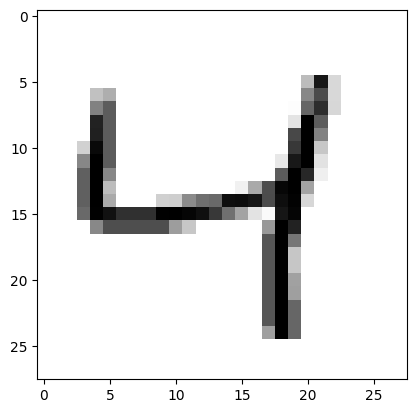

In [8]:
digit = train_images[2]

import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(digit, cmap=plt.cm.binary)

In [9]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

## 2. Create a fully-connect neural network model

In [10]:
from keras import models
from keras import layers

* `network = models.Sequential()`: Initializes a sequential model, which is a linear stack of layers.
* `network.add(layers.Dense(512, activation='relu',input_shape=(28*28,)))`: Adds the first layer, a densely connected layer with 512 units. It uses the ReLU activation function and specifies the input shape as 28*28, which is the flattened size of the MNIST images.
* `network.add(layers.Dense(10, activation='softmax'))`: Adds the output layer, another densely connected layer with 10 units (one for each digit 0-9). It uses the softmax activation function, which outputs a probability distribution over the 10 classes.

In [11]:
network = models.Sequential()
network.add(layers.Dense(512, activation='relu',input_shape=(28*28,)))
network.add(layers.Dense(10, activation='softmax'))

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


* `network.compile(...)`: This method configures the model for training.
* `optimizer='rmsprop'`: This specifies the optimization algorithm to be used during training. RMSprop is a popular choice for many neural networks.
* `loss='categorical_crossentropy'`: This defines the loss function that the model will try to minimize during training. Categorical crossentropy is commonly used for multi-class classification problems like this one, where the labels are one-hot encoded.
* `metrics=['accuracy']`: This specifies the metrics that will be used to evaluate the model's performance during training and testing. In this case, it's accuracy, which is the proportion of correctly classified samples.

In [12]:
network.compile(optimizer='rmsprop',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

In [13]:
network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Preprocessing Data

In [14]:
train_images = train_images.reshape(60000,28*28) # Reshape
train_images = train_images.astype('float32')/255 # Normalize

test_images = test_images.reshape(10000,28*28) # Reshape
test_images = test_images.astype('float32')/255 # Normalize

In [15]:
from keras.utils import to_categorical

In [16]:
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [17]:
test_labels

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 10))

In [18]:
test_labels.shape

(10000, 10)

## 4. Train Model

* `train_images` and `train_labels`: These are the training data and their corresponding labels.
* `epochs=5`: This specifies that the model will be trained for 5 epochs. An epoch is one complete pass through the entire training dataset.
* `batch_size=128`: This determines the number of samples per gradient update. The training data is divided into batches of 128 images, and the model's weights are updated after processing each batch.
* `history`: The results of the training process, including the loss and accuracy for each epoch, are stored in the history object.

In [19]:
history = network.fit(train_images,train_labels,epochs=5,batch_size=128)

Epoch 1/5


  1/469 ━━━━━━━━━━━━━━━━━━━━ 3:51 495ms/step - accuracy: 0.0938 - loss: 2.3925

 10/469 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6102 - loss: 1.3254    

 19/469 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7118 - loss: 1.0147

 28/469 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7600 - loss: 0.8471

...

437/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9888 - loss: 0.0397

446/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9888 - loss: 0.0395

456/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9888 - loss: 0.0395

466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9888 - loss: 0.0394

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9888 - loss: 0.0393


## 5. Evaluate Model

In [20]:
test_loss, test_acc = network.evaluate(test_images, test_labels)
print('Test Loss: %s\nTest Accuracy: %s' % (test_loss,test_acc))

  1/313 ━━━━━━━━━━━━━━━━━━━━ 41s 132ms/step - accuracy: 1.0000 - loss: 0.0034

 30/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9792 - loss: 0.0600   

 60/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9724 - loss: 0.0870

 86/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9709 - loss: 0.0944

114/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9731 - loss: 0.0906

...

239/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9788 - loss: 0.0695

270/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9799 - loss: 0.0655

301/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9814 - loss: 0.0610

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9810 - loss: 0.0625


Test Loss: 0.06253235787153244
Test Accuracy: 0.9810000061988831


In [21]:
history.history

{'accuracy': [0.9252166748046875,
  0.9687666893005371,
  0.9790666699409485,
  0.9848166704177856,
  0.9888333082199097],
 'loss': [0.2624933123588562,
  0.10727231204509735,
  0.07092484086751938,
  0.051619041711091995,
  0.03927827253937721]}